# Cost vs Elapsed Time by Optimizer

This notebook reads `RESULTS/optimizer_performance.csv` and plots cost vs elapsed time for each optimizer.
Each run is displayed as a separate line.

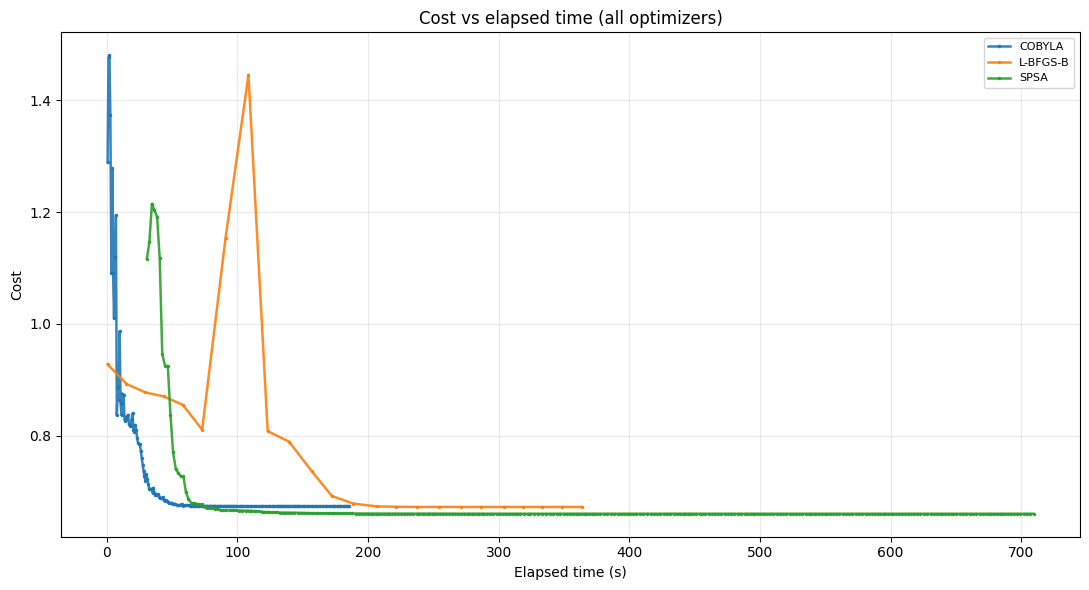

Optimizers plotted: COBYLA, L-BFGS-B, SPSA
Total rows used: 535


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_path = Path("RESULTS") / "optimizer_performance.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"CSV not found: {csv_path.resolve()}")

df = pd.read_csv(csv_path)
required_cols = {"optimizer", "run_id", "cost", "elapsed_seconds"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

# Keep rows that can be plotted on a numeric time axis.
df["elapsed_seconds"] = pd.to_numeric(df["elapsed_seconds"], errors="coerce")
df["cost"] = pd.to_numeric(df["cost"], errors="coerce")
df = df.dropna(subset=["elapsed_seconds", "cost", "optimizer", "run_id"]).copy()

if df.empty:
    raise ValueError("No plottable rows found (elapsed_seconds/cost are empty or invalid).")

optimizers = sorted(df["optimizer"].astype(str).unique())
fig, ax = plt.subplots(figsize=(11, 6))

for opt in optimizers:
    opt_df = df[df["optimizer"].astype(str) == opt].copy()
    run_ids = sorted(opt_df["run_id"].astype(str).unique())

    for run_id in run_ids:
        run_df = opt_df[opt_df["run_id"].astype(str) == run_id].sort_values("elapsed_seconds")
        label = opt if len(run_ids) == 1 else f"{opt} | run {run_id}"
        ax.plot(
            run_df["elapsed_seconds"],
            run_df["cost"],
            marker=".",
            linewidth=1.8,
            markersize=3,
            label=label,
            alpha=0.9,
        )

ax.set_title("Cost vs elapsed time (all optimizers)")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Cost")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

print("Optimizers plotted:", ", ".join(optimizers))
print("Total rows used:", len(df))